# capitulo3_pseudotime — Pseudotime Trajectory Analysis (Part 3)
## Requires: pbmc_harmony_curated.h5ad from capitulo1_single_cell.R

Run each section **in order**. Read the comments in each cell before changing parameters.


---
## SECTION 24 — Setup
Sets paths and loads libraries. Only change `PIPELINE_DIR` and `DATA_DIR` if your folder structure is different.


In [17]:
import os

# ── Paths (must match capitulo1_single_cell.R) ────────────────────────────────
PIPELINE_DIR = "/workspace/workflow_nuevo"
DATA_DIR     = "/workspace/."
base_dir     = os.path.join(DATA_DIR, "resultados")

# Load libraries and functions (equivalent to source() in R)
exec(open(os.path.join(PIPELINE_DIR, "load_libraries_python.py")).read(), globals())
exec(open(os.path.join(PIPELINE_DIR, "ScRNA_Pseudotime_Functions.py")).read(), globals())

dir_pseudotime = os.path.join(base_dir, "09_pseudotime")
os.makedirs(dir_pseudotime, exist_ok=True)

print("SECTION 24 COMPLETE: Setup done")

SECTION 24 COMPLETE: Setup done


---
## SECTION 25 — Load Data
Loads the AnnData object (`.h5ad`) exported from Seurat by capitulo1.

**What this section does:**
1. Reads the `.h5ad` file with all cells, genes, and metadata from capitulo1
2. Converts the UMAP and PCA coordinates from R format to scanpy format
3. Prints the available cell type names — **you will need these for Section 26**
4. Plots a UMAP as a visual check that the object loaded correctly

**Parameter to set:**
- `ANNOTATION_COL`: the column with your final cell type labels
  - Run `print(adata.obs.columns.tolist())` to see all available columns
  - Common options: `celltype_curated`, `celltype_reference`, `seurat_clusters`
- `N_JOBS`: CPU cores for parallel steps (4–8 on a laptop, up to 32 on server)


Loading object: /home/projects2/mvergara/eleo/ScRNA/metodologia/resultados/objects/pbmc_harmony_curated.h5ad


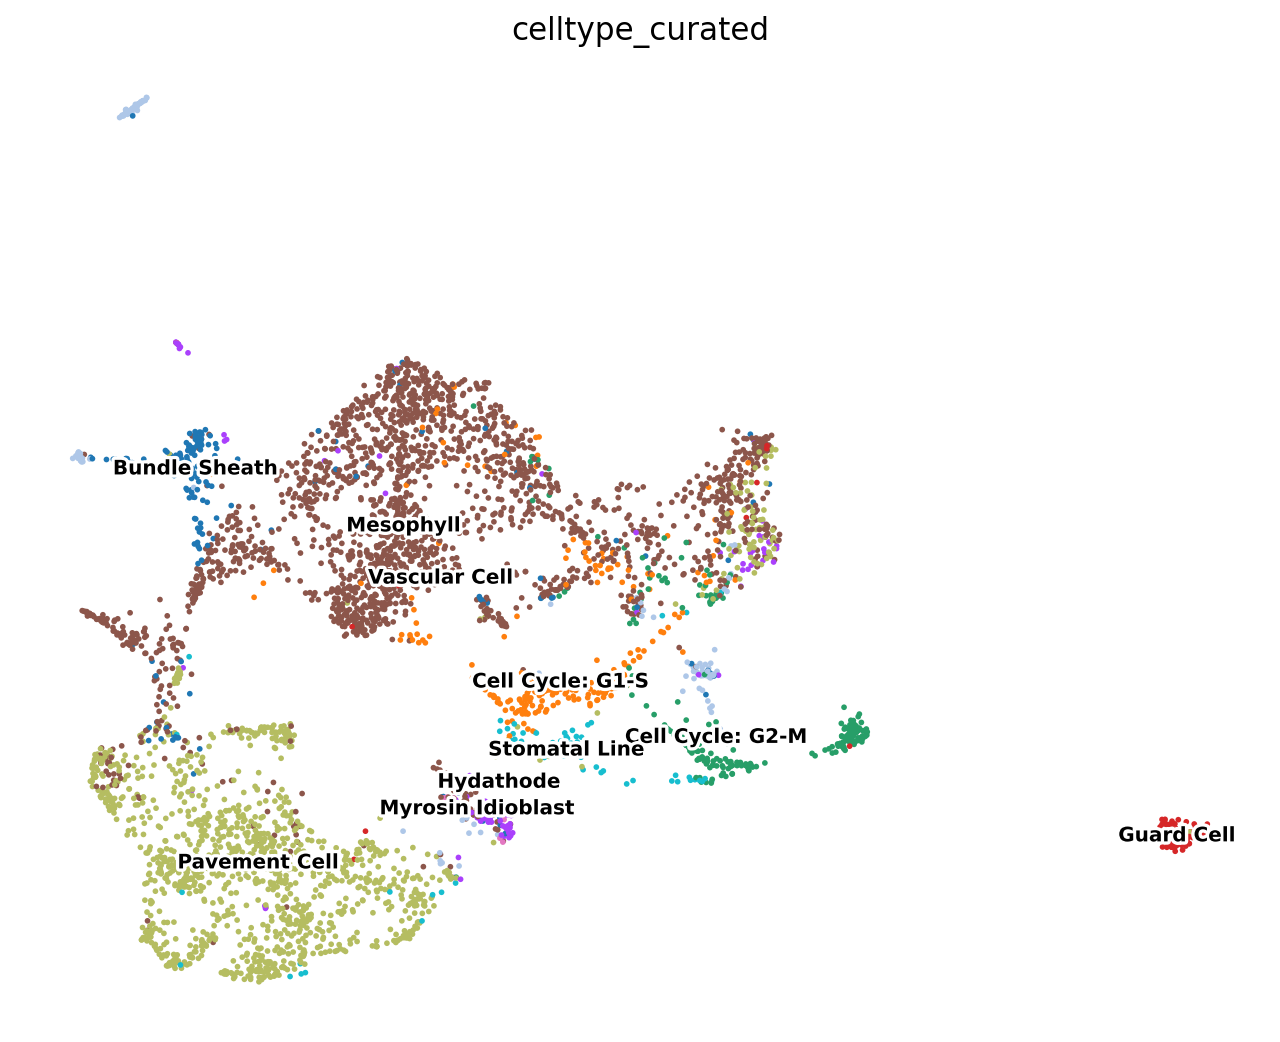


Cell types in 'celltype_curated':

   1.  Bundle Sheath                     210 cells
   2.  Cell Cycle: G1-S                  245 cells
   3.  Cell Cycle: G2-M                  240 cells
   4.  Guard Cell                        109 cells
   5.  Hydathode                         111 cells
   6.  Mesophyll                        2128 cells
   7.  Myrosin Idioblast                   6 cells
   8.  Pavement Cell                    1283 cells
   9.  Stomatal Line                      75 cells
  10.  Vascular Cell                     151 cells

STEP 25 COMPLETE: full object loaded


In [18]:
# STEP 25 — Load full object
# Change INPUT_H5AD only if you want to analyze a different object.

INPUT_H5AD = os.path.join("/workspace/resultados/objects/pbmc_harmony_curated.h5ad")
ANNOTATION_COL = "celltype_curated"
N_JOBS = 4

adata, N_JOBS = load_curated_object(
    input_h5ad     = INPUT_H5AD,
    dir_pseudotime = dir_pseudotime,
    annotation_col = ANNOTATION_COL,
    n_jobs         = N_JOBS,
)


---
## SECTION 26 — Cell Type Selection
Shows the available cell types and plots a UMAP of your selected subset.

**What to do:**
1. Run the cell — reads the available cell types and their counts
2. Edit `TRAJECTORY_CLUSTERS` with the names you want to include
3. Re-run — plots the subset UMAP so you can verify before continuing


Selected 1358 cells: ['Pavement Cell', 'Stomatal Line']


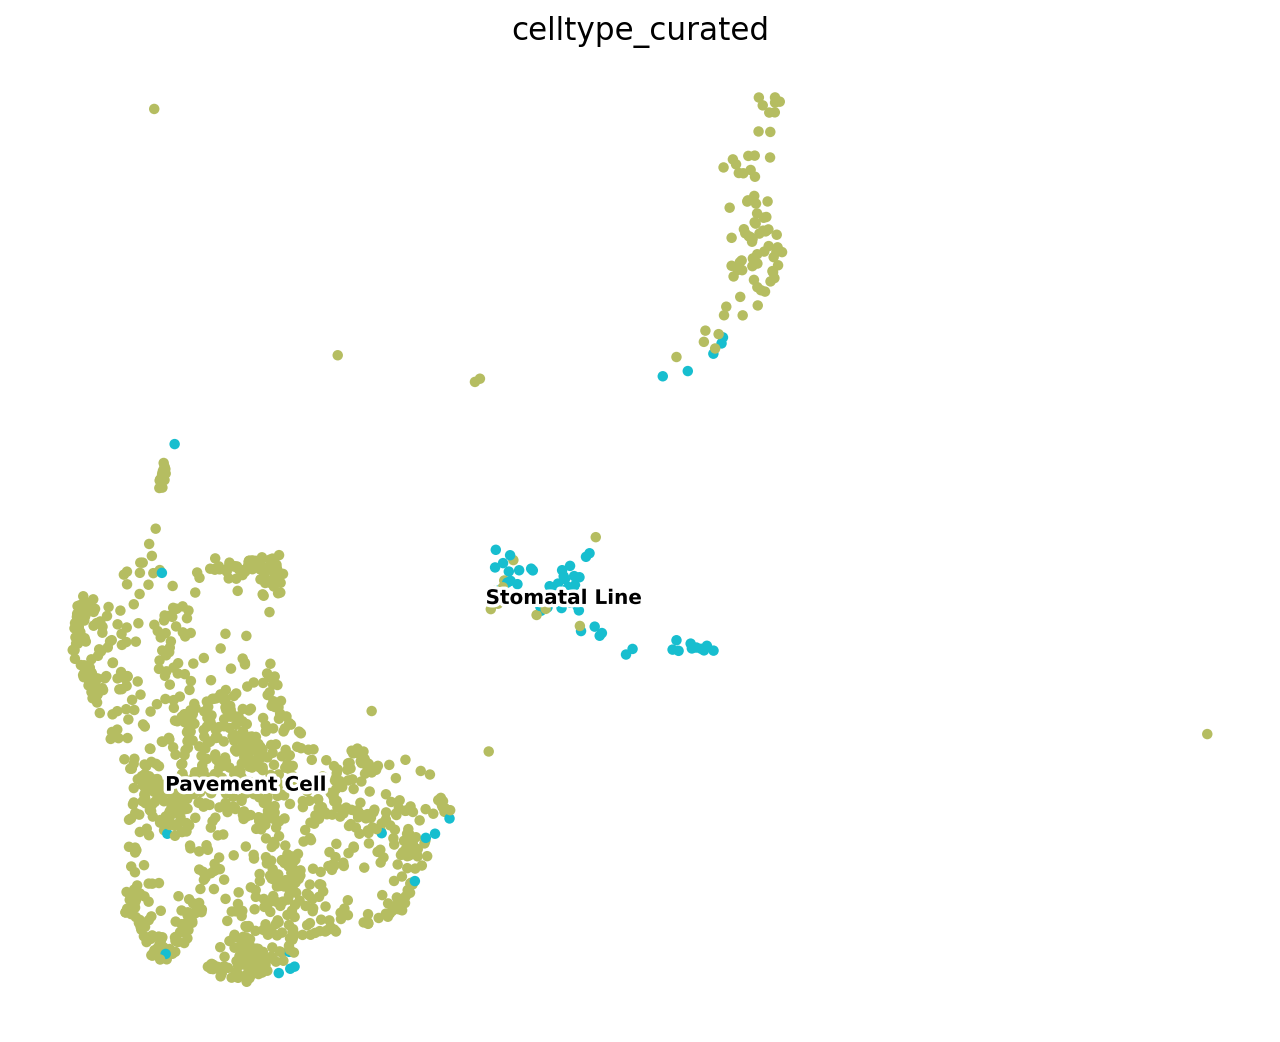


STEP 26 COMPLETE: continue only if this UMAP looks biologically sensible


In [19]:
# STEP 26 — Choose cell types for trajectory
# Copy names exactly from the Step 25 list.

TRAJECTORY_CLUSTERS = ["Pavement Cell", "Stomatal Line"]

adata_sub = preview_trajectory_selection(
    adata          = adata,
    clusters       = TRAJECTORY_CLUSTERS,
    annotation_col = ANNOTATION_COL,
    dir_pseudotime = dir_pseudotime,
)


---
## SECTION 27 — Trajectory Inference
Builds a tree-shaped trajectory through the cell types selected in Section 26.

**Parameters to set:**
- `ROOT_CLUSTER`: the progenitor — where pseudotime = 0 (must be one of your Section 26 types)
- `NODES`, `SIGMA`, `PPT_LAMBDA`, `N_EIGS`: tree shape (defaults work for most cases)
- `SEED`: random seed for the stochastic steps (neighbors, ForceAtlas2 layout, tree fitting) — same seed + same params always reproduces the same result


In [ ]:
# STEP 27 — Build trajectory
#
# ROOT_CLUSTER is chosen from biology: literature, markers, or prior knowledge.
# Add more trajectory_run(...) lines to test more configurations.
# The run name is generated automatically from nodes/sigma/lambda/eigs/seed.

ROOT_CLUSTER = "Stomatal Line"

TRAJECTORY_RUNS = [
    trajectory_run(nodes=100, sigma=0.1, lambda_value=200, eigs=8, seed=3),
]

adata_traj, selected_trajectory_dir, trajectory_runs = run_trajectory_runs(
    adata           = adata,
    clusters        = TRAJECTORY_CLUSTERS,
    root_cluster    = ROOT_CLUSTER,
    annotation_col  = ANNOTATION_COL,
    output_base_dir = dir_pseudotime,
    runs            = TRAJECTORY_RUNS,
)


---
## STEP 28 — Plot genes on trajectory
Plots pseudotime and the genes you list on the trajectory layout — one figure, all genes together. Plain scanpy, no wrapper function.
Edit only `GENES` in the code cell below.


In [ ]:
# STEP 28 — Plot genes on trajectory
# Edit only this list.

GENES = ["AT1G22690", "AT4G04890", "AT1G80070"]
name  = os.path.basename(selected_trajectory_dir)

if adata_traj.X is None and "logcounts" in adata_traj.layers:
    adata_traj.X = adata_traj.layers["logcounts"]

gene_plots_dir = os.path.join(selected_trajectory_dir, "gene_plots")
os.makedirs(gene_plots_dir, exist_ok=True)

fig = sc.pl.draw_graph(
    adata_traj,
    color=GENES,
    title=GENES,
    show=False,
    return_fig=True,
)
save_plot_18x18(fig, os.path.join(gene_plots_dir, f"{name}_gene_plots.png"))
save_plot_18x18(fig, os.path.join(gene_plots_dir, f"{name}_gene_plots.pdf"))
plt.close(fig)


---
## STEP 29 — Gene trends (top variable genes + custom highlight list)
Builds (if not already present) the dendrogram, `test_association`, and `fit` on the trajectory object, then produces two heatmaps:
1. Highlighting the `TOP_N` genes most strongly associated with the trajectory (highest `A` statistic).
2. Highlighting a `HIGHLIGHT_GENES` list you choose yourself.

**Parameters to set:**
- `TOP_N`: how many top-variable genes to highlight (default 50)
- `HIGHLIGHT_GENES`: list of gene IDs you want highlighted in the second heatmap
- `ORDERING`: how genes are ordered in the heatmap (`"max"`, `"pearson"`, or `"quantile"`)


In [ ]:
# STEP 29 — Gene trends: top variable genes + custom highlight list
# Edit TOP_N and HIGHLIGHT_GENES below.
# If you hit "fewer unique covariate combinations than specified maximum
# degrees of freedom", lower SPLINE_DF (e.g. 3) and re-run.

TOP_N = 10
HIGHLIGHT_GENES = ["AT1G22690", "AT4G04890", "AT1G80070"]
ORDERING = "max"
SPLINE_DF = 5

top_path, highlight_path = run_step29_gene_trends(
    adata=adata_traj,
    run_dir=selected_trajectory_dir,
    name=os.path.basename(selected_trajectory_dir),
    custom_genes=HIGHLIGHT_GENES,
    top_n=TOP_N,
    ordering=ORDERING,
    spline_df=SPLINE_DF,
)
